<a href="https://colab.research.google.com/github/gupadovezi/gupadovezi/blob/main/Digital_Twins_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

# Verificar se a GPU está disponível e qual tipo de GPU
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar TensorFlow para usar a GPU
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU disponível:", gpus[0])
        # Optional: Check if it's a T4
        print("Detalhes da GPU (se disponível):", tf.config.experimental.get_device_details(gpus[0]))
    except RuntimeError as e:
        print(e)
else:
    print("Nenhuma GPU encontrada. O TensorFlow será executado na CPU.")

TensorFlow version: 2.20.0
Nenhuma GPU encontrada. O TensorFlow será executado na CPU.


In [ ]:
# Geração de Dados Sintéticos para Perfis de Pacientes

# Definir o número de pacientes virtuais
num_patients = 1000

# Gerar características demográficas e clínicas basais
np.random.seed(42) # Para reprodutibilidade

# Idade: distribuição normal com média 50, desvio padrão 15
age = np.random.normal(loc=50, scale=15, size=num_patients).astype(int)
age = np.clip(age, 20, 80) # Limitar a idade a um intervalo razoável

# Gênero: 0 para masculino, 1 para feminino
gender = np.random.randint(0, 2, size=num_patients)

# Intensidade da Dor (Escala Numérica 0-10): Distribuição mais para dores moderadas a severas
pain_intensity_baseline = np.random.normal(loc=6, scale=2, size=num_patients)
pain_intensity_baseline = np.clip(pain_intensity_baseline, 0, 10).round(1)

# Incapacidade Funcional (Roland Morris 0-24): Correlacionado com a dor
functional_disability_baseline = np.random.normal(loc=12, scale=5, size=num_patients)
functional_disability_baseline = np.clip(functional_disability_baseline, 0, 24).astype(int)
# Adicionar alguma correlação: pacientes com mais dor tendem a ter mais incapacidade
functional_disability_baseline = functional_disability_baseline + (pain_intensity_baseline * 0.5)
functional_disability_baseline = np.clip(functional_disability_baseline, 0, 24).astype(int)

# Duração da Dor Crônica (em meses)
duration_of_pain_months = np.random.exponential(scale=12, size=num_patients)
duration_of_pain_months = np.clip(duration_of_pain_months, 1, 60).astype(int)

# Comorbidades (simples: número de comorbidades)
num_comorbidities = np.random.poisson(lam=1.5, size=num_patients)
num_comorbidities = np.clip(num_comorbidities, 0, 5)

# Criar DataFrame
df_patients = pd.DataFrame({
    'patient_id': range(1, num_patients + 1),
    'age': age,
    'gender': gender, # 0=Male, 1=Female
    'pain_intensity_baseline': pain_intensity_baseline,
    'functional_disability_baseline': functional_disability_baseline,
    'duration_of_pain_months': duration_of_pain_months,
    'num_comorbidities': num_comorbidities
})

print(f"Gerados {num_patients} perfis de pacientes sintéticos.")
display(df_patients.head())

# Exibir estatísticas descritivas para verificar a plausibilidade
print("\nEstatísticas Descritivas dos Dados Sintéticos:")
display(df_patients.describe())

Gerados 1000 perfis de pacientes sintéticos.


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
0,1,57,0,5.3,13,6,1
1,2,47,1,6.4,7,10,1
2,3,59,0,3.3,8,1,3
3,4,72,1,4.1,8,33,1
4,5,46,0,8.4,17,16,3



Estatísticas Descritivas dos Dados Sintéticos:


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.756000,0.511000,6.043400,14.041000,11.353000,1.432000
std,288.819436,14.148875,0.500129,1.926979,5.025592,11.405458,1.132545
min,1.000000,20.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,250.750000,40.000000,0.000000,4.800000,11.000000,3.000000,1.000000
50%,500.500000,50.000000,1.000000,6.000000,14.000000,7.000000,1.000000
75%,750.250000,59.000000,1.000000,7.400000,18.000000,16.000000,2.000000
max,1000.000000,80.000000,1.000000,10.000000,24.000000,60.000000,5.000000


Trajetórias clínicas simuladas geradas.


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities,pain_intensity_3m,functional_disability_3m,pain_intensity_6m,functional_disability_6m,pain_intensity_12m,functional_disability_12m
0,1,57,0,5.3,13,6,1,4.2,12,2.7,5,2.5,5
1,2,47,1,6.4,7,10,1,4.5,6,3.0,2,1.5,4
2,3,59,0,3.3,8,1,3,2.7,5,1.4,2,2.0,0
3,4,72,1,4.1,8,33,1,4.1,4,2.5,6,0.6,4
4,5,46,0,8.4,17,16,3,6.0,13,2.9,11,0.9,10


Conjuntos de treino e teste criados: Treino=800 amostras, Teste=200 amostras.
Treinando modelo para 'pain_intensity_3m'...

Desempenho do Modelo para Dor em 3 meses:
MAE: 0.09
R²: 0.99

Treinando modelo para 'functional_disability_3m'...

Desempenho do Modelo para Incapacidade em 3 meses:
MAE: 1.75
R²: 0.76


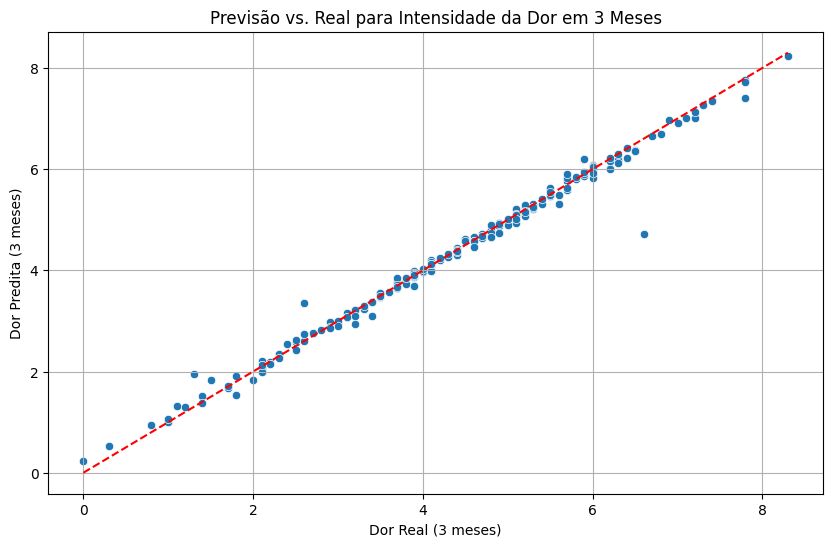


Modelos preditivos para dor e incapacidade em 3 meses foram treinados e avaliados.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2.1. Simulação das Trajetórias Clínicas (Ground Truth Sintético) ---

# Simular desfechos em 3, 6 e 12 meses
def simulate_trajectory(df, month_factor=0.8, noise_level=1.0):
    df_traj = df.copy()
    np.random.seed(42) # Para consistência na simulação

    # Simular dor e incapacidade ao longo do tempo
    # Assumimos uma tendência geral de melhora, mas com variabilidade e dependência do baseline

    # Simulação para 3 meses
    df_traj['pain_intensity_3m'] = np.clip(
        df_traj['pain_intensity_baseline'] * month_factor - (df_traj['age'] / 100) + np.random.normal(0, noise_level, len(df_traj)),
        0, 10
    ).round(1)
    df_traj['functional_disability_3m'] = np.clip(
        df_traj['functional_disability_baseline'] * month_factor - (df_traj['num_comorbidities'] * 0.5) + np.random.normal(0, noise_level*2, len(df_traj)),
        0, 24
    ).astype(int)

    # Simulação para 6 meses (melhora contínua, mas mais lenta)
    df_traj['pain_intensity_6m'] = np.clip(
        df_traj['pain_intensity_3m'] * month_factor - (df_traj['gender'] * 0.5) + np.random.normal(0, noise_level, len(df_traj)),
        0, 10
    ).round(1)
    df_traj['functional_disability_6m'] = np.clip(
        df_traj['functional_disability_3m'] * month_factor - (df_traj['age'] / 100) + np.random.normal(0, noise_level*2, len(df_traj)),
        0, 24
    ).astype(int)

    # Simulação para 12 meses (estabilização ou pequena melhora/piora dependendo do indivíduo)
    df_traj['pain_intensity_12m'] = np.clip(
        df_traj['pain_intensity_6m'] * (1 + np.random.uniform(-0.1, 0.1, len(df_traj))) + np.random.normal(0, noise_level, len(df_traj)),
        0, 10
    ).round(1)
    df_traj['functional_disability_12m'] = np.clip(
        df_traj['functional_disability_6m'] * (1 + np.random.uniform(-0.1, 0.1, len(df_traj))) + np.random.normal(0, noise_level*2, len(df_traj)),
        0, 24
    ).astype(int)

    return df_traj

# Gerar o DataFrame com as trajetórias simuladas
df_trajectories = simulate_trajectory(df_patients)

print("Trajetórias clínicas simuladas geradas.")
display(df_trajectories.head())

# --- 2.2. Construção e Avaliação de Modelos Preditivos ---

# Definir features (X) e targets (Y) para o modelo preditivo
# Usaremos as características basais para prever os desfechos simulados
X = df_trajectories[['age', 'gender', 'pain_intensity_baseline', 'functional_disability_baseline', 'duration_of_pain_months', 'num_comorbidities']]
y_pain_3m = df_trajectories['pain_intensity_3m']
y_disability_3m = df_trajectories['functional_disability_3m']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_pain_train, y_pain_test = train_test_split(X, y_pain_3m, test_size=0.2, random_state=42)
_, _, y_disability_train, y_disability_test = train_test_split(X, y_disability_3m, test_size=0.2, random_state=42)

print(f"Conjuntos de treino e teste criados: Treino={len(X_train)} amostras, Teste={len(X_test)} amostras.")

# Treinar um modelo RandomForestRegressor para prever dor em 3 meses
model_pain_3m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos os cores disponíveis
print("Treinando modelo para 'pain_intensity_3m'...")
model_pain_3m.fit(X_train, y_pain_train)
y_pain_pred = model_pain_3m.predict(X_test)

print(f"\nDesempenho do Modelo para Dor em 3 meses:")
print(f"MAE: {mean_absolute_error(y_pain_test, y_pain_pred):.2f}")
print(f"R²: {r2_score(y_pain_test, y_pain_pred):.2f}")

# Treinar um modelo RandomForestRegressor para prever incapacidade em 3 meses
model_disability_3m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("\nTreinando modelo para 'functional_disability_3m'...")
model_disability_3m.fit(X_train, y_disability_train)
y_disability_pred = model_disability_3m.predict(X_test)

print(f"\nDesempenho do Modelo para Incapacidade em 3 meses:")
print(f"MAE: {mean_absolute_error(y_disability_test, y_disability_pred):.2f}")
print(f"R²: {r2_score(y_disability_test, y_disability_pred):.2f}")

# Visualização dos resultados para um dos desfechos (e.g., dor em 3 meses)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pain_test, y=y_pain_pred)
plt.plot([y_pain_test.min(), y_pain_test.max()], [y_pain_test.min(), y_pain_test.max()], 'r--')
plt.xlabel("Dor Real (3 meses)")
plt.ylabel("Dor Predita (3 meses)")
plt.title("Previsão vs. Real para Intensidade da Dor em 3 Meses")
plt.grid(True)
plt.show()

print("\nModelos preditivos para dor e incapacidade em 3 meses foram treinados e avaliados.")


In [ ]:
# --- 3.1. Randomização dos Gêmeos Digitais ---

# Definir os 4 modelos de cuidado
care_models = [
    'usual care',
    'digital care / patient education',
    'AI intervention without prompt engineering',
    'AI intervention with prompt engineering'
]

# Randomizar cada paciente para um dos 4 modelos de cuidado
np.random.seed(42)
df_trajectories['assigned_care_model'] = np.random.choice(care_models, size=len(df_trajectories))

print("Pacientes randomizados para os modelos de cuidado:")
display(df_trajectories['assigned_care_model'].value_counts())

# --- 3.2. Simulação de Trajetórias com Base no Modelo de Cuidado ---

# Definir efeitos hipotéticos dos modelos de cuidado nos desfechos (e.g., redução de dor/incapacidade)
# Estes são valores hipotéticos e devem ser baseados em suposições clínicas para o seu estudo.
# Valores negativos indicam melhora (redução na dor/incapacidade).
care_effect_pain = {
    'usual care': {'3m': 0.5, '6m': 0.3, '12m': 0.2}, # Pequena melhora
    'digital care / patient education': {'3m': -0.5, '6m': -0.8, '12m': -0.7}, # Melhora moderada
    'AI intervention without prompt engineering': {'3m': -1.0, '6m': -1.5, '12m': -1.2}, # Melhora significativa
    'AI intervention with prompt engineering': {'3m': -1.5, '6m': -2.0, '12m': -1.8} # Melhoria ainda maior
}

care_effect_disability = {
    'usual care': {'3m': 1, '6m': 0.5, '12m': 0.2}, # Pequena melhora
    'digital care / patient education': {'3m': -2, '6m': -3, '12m': -2.5}, # Melhora moderada
    'AI intervention without prompt engineering': {'3m': -4, '6m': -5, '12m': -4.5}, # Melhora significativa
    'AI intervention with prompt engineering': {'3m': -5, '6m': -7, '12m': -6}
} # Melhoria ainda maior

# Função para simular trajetórias com o efeito do modelo de cuidado
def simulate_trajectory_with_care(df_initial, care_effects_pain, care_effects_disability, noise_level=1.0):
    df_simulated = df_initial.copy()
    np.random.seed(42) # Para reprodutibilidade da simulação base

    time_points = ['3m', '6m', '12m']

    for i, row in df_simulated.iterrows():
        model = row['assigned_care_model']
        # Baseline values from original df_trajectories (which already had some basic trajectory simulation)
        # We will apply care model effects on top of a more 'neutral' trajectory or on the baseline then evolve
        # For simplicity here, let's re-simulate based on baseline, applying the care model effect.
        # In a real scenario, this would be more complex, potentially involving recurrent models.

        # Using the base simulate_trajectory for a 'neutral' path, then adjusting
        # For this example, let's directly adjust baseline for simplicity for each time point
        # A more sophisticated model would use the predictive models previously trained

        # Simulate Pain
        df_simulated.loc[i, 'sim_pain_3m'] = np.clip(
            row['pain_intensity_baseline'] * 0.8 + np.random.normal(0, noise_level) + care_effects_pain[model]['3m'],
            0, 10
        ).round(1)
        df_simulated.loc[i, 'sim_pain_6m'] = np.clip(
            row['pain_intensity_baseline'] * 0.7 + np.random.normal(0, noise_level) + care_effects_pain[model]['6m'],
            0, 10
        ).round(1)
        df_simulated.loc[i, 'sim_pain_12m'] = np.clip(
            row['pain_intensity_baseline'] * 0.6 + np.random.normal(0, noise_level) + care_effects_pain[model]['12m'],
            0, 10
        ).round(1)

        # Simulate Disability
        df_simulated.loc[i, 'sim_functional_disability_3m'] = np.clip(
            row['functional_disability_baseline'] * 0.8 + np.random.normal(0, noise_level * 2) + care_effects_disability[model]['3m'],
            0, 24
        ).astype(int)
        df_simulated.loc[i, 'sim_functional_disability_6m'] = np.clip(
            row['functional_disability_baseline'] * 0.7 + np.random.normal(0, noise_level * 2) + care_effects_disability[model]['6m'],
            0, 24
        ).astype(int)
        df_simulated.loc[i, 'sim_functional_disability_12m'] = np.clip(
            row['functional_disability_baseline'] * 0.6 + np.random.normal(0, noise_level * 2) + care_effects_disability[model]['12m'],
            0, 24
        ).astype(int)

    return df_simulated

# Executar a simulação com efeitos dos modelos de cuidado
df_simulated_outcomes = simulate_trajectory_with_care(df_trajectories, care_effect_pain, care_effect_disability)

print("\nSimulação de desfechos com base nos modelos de cuidado concluída.")
display(df_simulated_outcomes[['patient_id', 'assigned_care_model', 'pain_intensity_baseline', 'sim_pain_3m', 'sim_pain_6m', 'sim_pain_12m', 'functional_disability_baseline', 'sim_functional_disability_3m', 'sim_functional_disability_6m', 'sim_functional_disability_12m']].head())

# Verificar a distribuição dos desfechos simulados por grupo
print("\nDistribuição média de dor em 12 meses por modelo de cuidado:")
print(df_simulated_outcomes.groupby('assigned_care_model')['sim_pain_12m'].mean())

print("\nDistribuição média de incapacidade em 12 meses por modelo de cuidado:")
print(df_simulated_outcomes.groupby('assigned_care_model')['sim_functional_disability_12m'].mean())

Pacientes randomizados para os modelos de cuidado:


,count
assigned_care_model,
AI intervention with prompt engineering,280
usual care,258
AI intervention without prompt engineering,232
digital care / patient education,230



Simulação de desfechos com base nos modelos de cuidado concluída.


,patient_id,assigned_care_model,pain_intensity_baseline,sim_pain_3m,sim_pain_6m,sim_pain_12m,functional_disability_baseline,sim_functional_disability_3m,sim_functional_disability_6m,sim_functional_disability_12m
0,1,AI intervention without prompt engineering,5.3,3.7,2.1,2.6,13,9.0,3.0,2.0
1,2,AI intervention with prompt engineering,6.4,5.2,3.2,1.6,7,1.0,0.0,0.0
2,3,usual care,3.3,3.4,0.7,0.5,8,6.0,4.0,5.0
3,4,AI intervention without prompt engineering,4.1,1.4,0.0,2.7,8,1.0,0.0,0.0
4,5,AI intervention without prompt engineering,8.4,5.2,4.5,2.7,17,10.0,5.0,5.0



Distribuição média de dor em 12 meses por modelo de cuidado:
assigned_care_model
AI intervention with prompt engineering       1.880000
AI intervention without prompt engineering    2.488362
digital care / patient education              2.985652
usual care                                    3.856202
Name: sim_pain_12m, dtype: float64

Distribuição média de incapacidade em 12 meses por modelo de cuidado:
assigned_care_model
AI intervention with prompt engineering       2.903571
AI intervention without prompt engineering    3.637931
digital care / patient education              5.739130
usual care                                    7.996124
Name: sim_functional_disability_12m, dtype: float64


Calculadas as mudanças em relação ao baseline para dor e incapacidade.


,patient_id,assigned_care_model,pain_intensity_baseline,delta_pain_12m,functional_disability_baseline,delta_disability_12m
0,1,AI intervention without prompt engineering,5.3,2.7,13,11.0
1,2,AI intervention with prompt engineering,6.4,4.8,7,7.0
2,3,usual care,3.3,2.8,8,3.0
3,4,AI intervention without prompt engineering,4.1,1.4,8,8.0
4,5,AI intervention without prompt engineering,8.4,5.7,17,12.0


/tmp/ipykernel_2520/1080406129.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='assigned_care_model', y='delta_pain_12m', data=df_simulated_outcomes, palette='viridis')


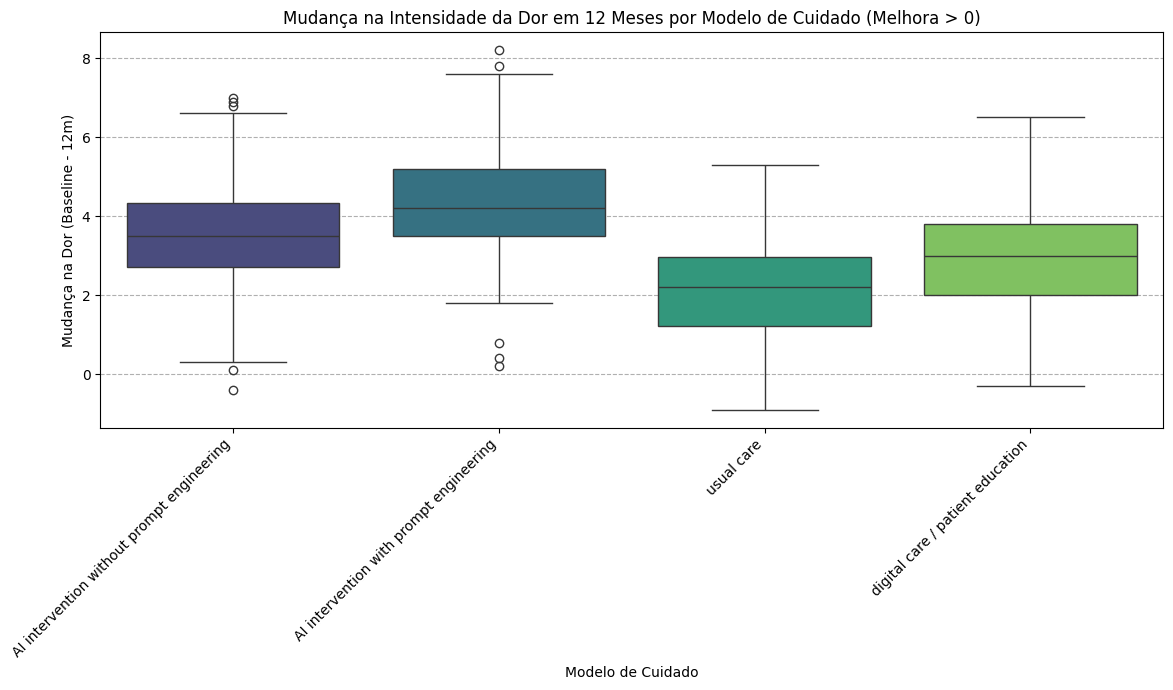

/tmp/ipykernel_2520/1080406129.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='assigned_care_model', y='delta_disability_12m', data=df_simulated_outcomes, palette='cividis')


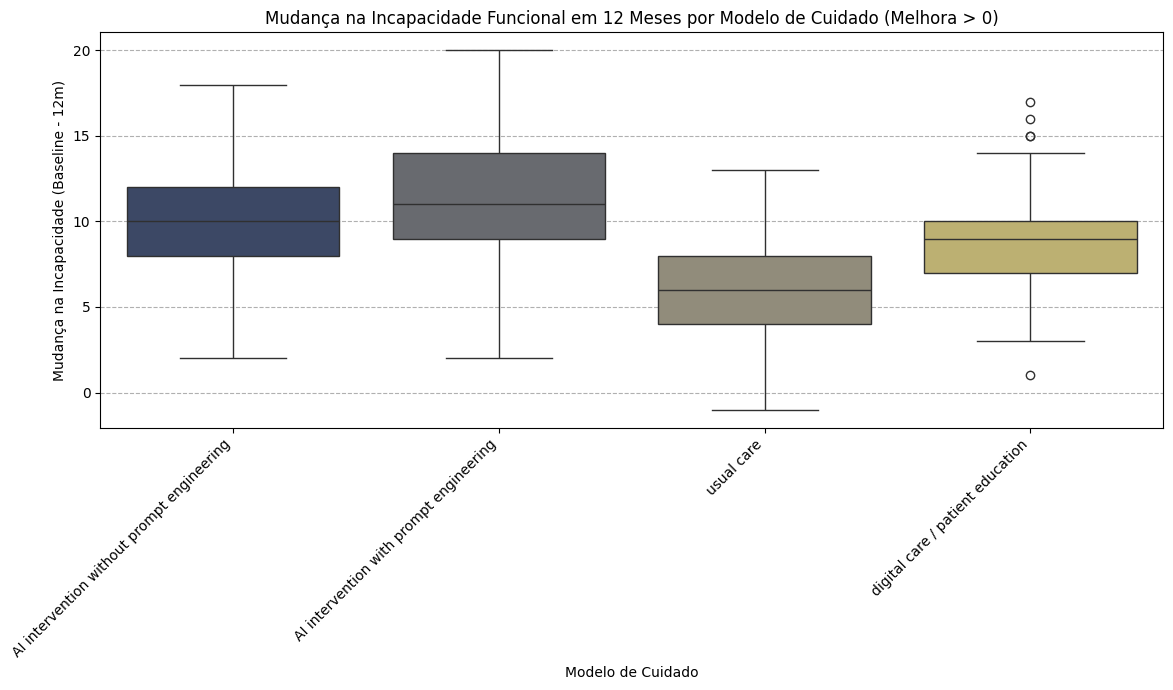


Realizando testes ANOVA para comparar a mudança na dor e incapacidade entre os grupos...

ANOVA para Mudança na Dor em 12 Meses: F-statistic=137.94, p-value=0.000
Existem diferenças estatisticamente significativas na mudança da dor entre os grupos.

ANOVA para Mudança na Incapacidade em 12 Meses: F-statistic=181.12, p-value=0.000
Existem diferenças estatisticamente significativas na mudança da incapacidade entre os grupos.


In [ ]:
from scipy.stats import f_oneway

# --- 4.1. Calcular Mudança em Relação ao Baseline ---

# Criar colunas para a mudança (melhora/piora) na dor e incapacidade em cada ponto de tempo
df_simulated_outcomes['delta_pain_3m'] = df_simulated_outcomes['pain_intensity_baseline'] - df_simulated_outcomes['sim_pain_3m']
df_simulated_outcomes['delta_pain_6m'] = df_simulated_outcomes['pain_intensity_baseline'] - df_simulated_outcomes['sim_pain_6m']
df_simulated_outcomes['delta_pain_12m'] = df_simulated_outcomes['pain_intensity_baseline'] - df_simulated_outcomes['sim_pain_12m']

df_simulated_outcomes['delta_disability_3m'] = df_simulated_outcomes['functional_disability_baseline'] - df_simulated_outcomes['sim_functional_disability_3m']
df_simulated_outcomes['delta_disability_6m'] = df_simulated_outcomes['functional_disability_baseline'] - df_simulated_outcomes['sim_functional_disability_6m']
df_simulated_outcomes['delta_disability_12m'] = df_simulated_outcomes['functional_disability_baseline'] - df_simulated_outcomes['sim_functional_disability_12m']

print("Calculadas as mudanças em relação ao baseline para dor e incapacidade.")
display(df_simulated_outcomes[['patient_id', 'assigned_care_model', 'pain_intensity_baseline', 'delta_pain_12m', 'functional_disability_baseline', 'delta_disability_12m']].head())

# --- 4.2. Análise Comparativa e Visualização ---

# Visualização da distribuição da mudança de dor em 12 meses por grupo
plt.figure(figsize=(12, 7))
sns.boxplot(x='assigned_care_model', y='delta_pain_12m', data=df_simulated_outcomes, palette='viridis')
plt.title('Mudança na Intensidade da Dor em 12 Meses por Modelo de Cuidado (Melhora > 0)')
plt.xlabel('Modelo de Cuidado')
plt.ylabel('Mudança na Dor (Baseline - 12m)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Visualização da distribuição da mudança de incapacidade em 12 meses por grupo
plt.figure(figsize=(12, 7))
sns.boxplot(x='assigned_care_model', y='delta_disability_12m', data=df_simulated_outcomes, palette='cividis')
plt.title('Mudança na Incapacidade Funcional em 12 Meses por Modelo de Cuidado (Melhora > 0)')
plt.xlabel('Modelo de Cuidado')
plt.ylabel('Mudança na Incapacidade (Baseline - 12m)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# --- 4.3. Testes Estatísticos (ANOVA) ---

print("\nRealizando testes ANOVA para comparar a mudança na dor e incapacidade entre os grupos...")

# Preparar dados para ANOVA para mudança na dor em 12 meses
pain_groups = [df_simulated_outcomes['delta_pain_12m'][df_simulated_outcomes['assigned_care_model'] == model]
               for model in care_models]
f_stat_pain, p_val_pain = f_oneway(*pain_groups)

print(f"\nANOVA para Mudança na Dor em 12 Meses: F-statistic={f_stat_pain:.2f}, p-value={p_val_pain:.3f}")
if p_val_pain < 0.05:
    print("Existem diferenças estatisticamente significativas na mudança da dor entre os grupos.")
else:
    print("Não há diferenças estatisticamente significativas na mudança da dor entre os grupos.")

# Preparar dados para ANOVA para mudança na incapacidade em 12 meses
disability_groups = [df_simulated_outcomes['delta_disability_12m'][df_simulated_outcomes['assigned_care_model'] == model]
                     for model in care_models]
f_stat_disability, p_val_disability = f_oneway(*disability_groups)

print(f"\nANOVA para Mudança na Incapacidade em 12 Meses: F-statistic={f_stat_disability:.2f}, p-value={p_val_disability:.3f}")
if p_val_disability < 0.05:
    print("Existem diferenças estatisticamente significativas na mudança da incapacidade entre os grupos.")
else:
    print("Não há diferenças estatisticamente significativas na mudança da incapacidade entre os grupos.")



--- Teste Post-Hoc Tukey HSD para Mudança na Dor em 12 Meses ---
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                    
                  group1                                     group2                   meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------------------------------------------------
   AI intervention with prompt engineering AI intervention without prompt engineering   -0.801   0.0 -1.0919   -0.51   True
   AI intervention with prompt engineering           digital care / patient education  -1.3634   0.0 -1.6551 -1.0718   True
   AI intervention with prompt engineering                                 usual care  -2.1733   0.0 -2.4561 -1.8904   True
AI intervention without prompt engineering           digital care / patient education  -0.5625   0.0 -0.8674 -0.2575   True
AI intervention without prompt engineering                        

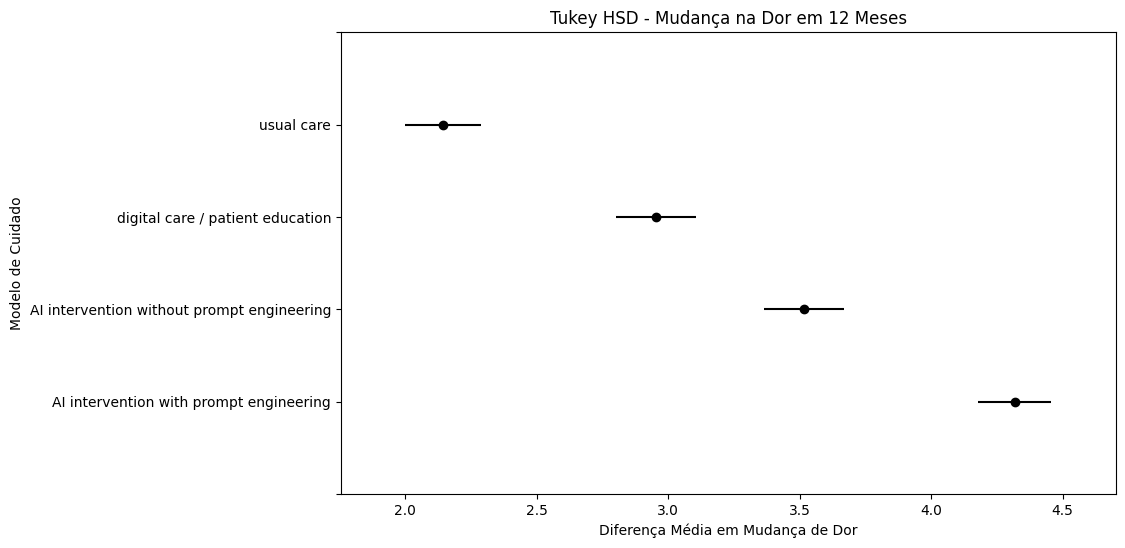


--- Teste Post-Hoc Tukey HSD para Mudança na Incapacidade em 12 Meses ---
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                    
                  group1                                     group2                   meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------------------------------------------------
   AI intervention with prompt engineering AI intervention without prompt engineering  -1.2209   0.0 -1.9158  -0.526   True
   AI intervention with prompt engineering           digital care / patient education  -2.7843   0.0 -3.4809 -2.0878   True
   AI intervention with prompt engineering                                 usual care   -5.843   0.0 -6.5185 -5.1675   True
AI intervention without prompt engineering           digital care / patient education  -1.5634   0.0 -2.2917 -0.8351   True
AI intervention without prompt engineering               

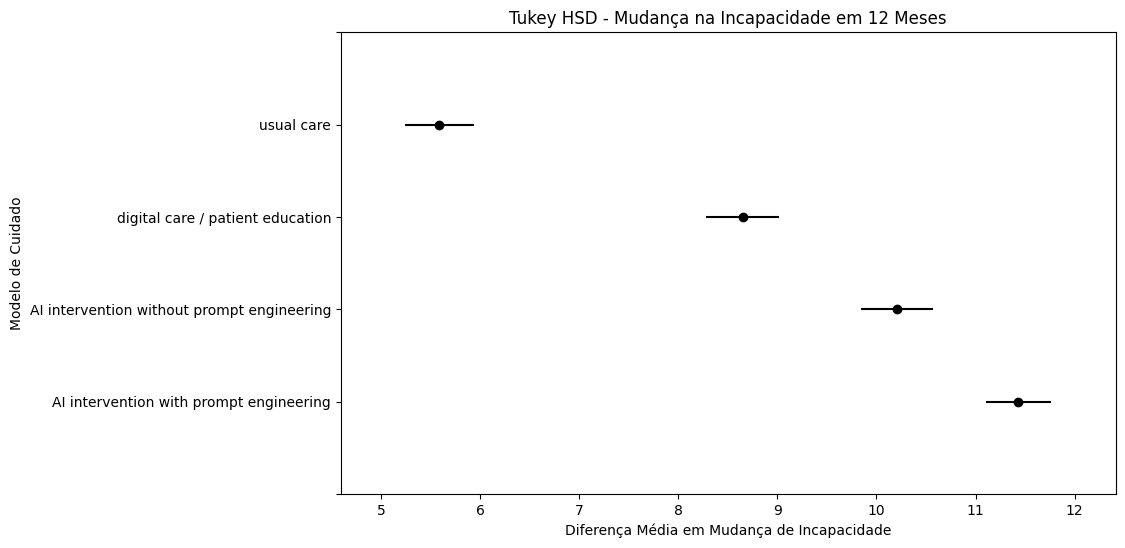


Testes post-hoc Tukey HSD concluídos para dor e incapacidade.


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 5.1. Teste Post-Hoc Tukey HSD para Mudança na Dor em 12 Meses ---

print("\n--- Teste Post-Hoc Tukey HSD para Mudança na Dor em 12 Meses ---")
tukey_pain = pairwise_tukeyhsd(
    endog=df_simulated_outcomes['delta_pain_12m'],
    groups=df_simulated_outcomes['assigned_care_model'],
    alpha=0.05
)
print(tukey_pain)

# Visualização dos resultados do Tukey HSD para dor
tukey_pain.plot_simultaneous(ylabel="Modelo de Cuidado", xlabel="Diferença Média em Mudança de Dor")
plt.title('Tukey HSD - Mudança na Dor em 12 Meses')
plt.show()

# --- 5.2. Teste Post-Hoc Tukey HSD para Mudança na Incapacidade em 12 Meses ---

print("\n--- Teste Post-Hoc Tukey HSD para Mudança na Incapacidade em 12 Meses ---")
tukey_disability = pairwise_tukeyhsd(
    endog=df_simulated_outcomes['delta_disability_12m'],
    groups=df_simulated_outcomes['assigned_care_model'],
    alpha=0.05
)
print(tukey_disability)

# Visualização dos resultados do Tukey HSD para incapacidade
tukey_disability.plot_simultaneous(ylabel="Modelo de Cuidado", xlabel="Diferença Média em Mudança de Incapacidade")
plt.title('Tukey HSD - Mudança na Incapacidade em 12 Meses')
plt.show()

print("\nTestes post-hoc Tukey HSD concluídos para dor e incapacidade.")

In [ ]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.8 MB/s eta 0:00:00


In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata # Reverting to SingleTableMetadata

# Create metadata from the real data
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_patients)

# Recommended: Save the metadata for reproducibility (as suggested by the library)
# metadata.save_to_json('df_patients_metadata.json')

# Create the synthesizer
synthesizer = CTGANSynthesizer(metadata)

# Train the synthesizer on the real data
synthesizer.fit(df_patients)

# Generate synthetic data
synthetic_data = synthesizer.sample(num_rows=100)

print("Synthetic data generated:")
display(synthetic_data.head())

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Synthetic data generated:


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
0,13757301,80,0,3.5,11,22,2
1,3578873,64,0,6.8,12,6,1
2,7196201,63,0,2.7,9,1,1
3,2219795,73,0,4.6,20,8,1
4,6480141,75,1,10.0,15,1,2


In [ ]:
from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata

# Create metadata for the real data
real_data_metadata = SingleTableMetadata()
real_data_metadata.detect_from_dataframe(data=df_patients)

# Although metadata is passed to the report, it is good practice to ensure consistency.
# synthetic_data_metadata = SingleTableMetadata()
# synthetic_data_metadata.detect_from_dataframe(data=synthetic_data)

# Create a QualityReport instance
report = QualityReport()

# Generate the diagnostic report to compare the real and synthetic data
report.generate(
    real_data=df_patients,
    synthetic_data=synthetic_data,
    metadata=real_data_metadata.to_dict() # Convert metadata object to dictionary
)

print("SDMetrics Diagnostic Report (Quality Report Scores):")
print(f"Overall Score (Average): {report.get_score()*100:.2f}%")

print("\nVisualizing 'Column Shapes' Report:")
display(report.get_visualization('Column Shapes'))

print("\nVisualizing 'Column Pair Trends' Report:")
display(report.get_visualization('Column Pair Trends'))


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 7/7 [00:00<00:00, 463.54it/s]|
Column Shapes Score: 78.72%

(2/2) Evaluating Column Pair Trends: |██████████| 21/21 [00:00<00:00, 247.18it/s]|
Column Pair Trends Score: nan%

Overall Score (Average): 78.72%

SDMetrics Diagnostic Report (Quality Report Scores):
Overall Score (Average): 78.72%

Visualizing 'Column Shapes' Report:



Visualizing 'Column Pair Trends' Report:


## Comparing Synthesizers

### GaussianCopulaSynthesizer

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdmetrics.reports.single_table import QualityReport
# Reuse the existing metadata (SingleTableMetadata is deprecated but was used before)
# metadata was created from df_patients earlier.

print("Generating synthetic data using GaussianCopulaSynthesizer...")
# Create the synthesizer
gc_synthesizer = GaussianCopulaSynthesizer(metadata)

# Train the synthesizer on the real data
gc_synthesizer.fit(df_patients)

# Generate synthetic data
gc_synthetic_data = gc_synthesizer.sample(num_rows=len(df_patients))

print("Synthetic data generated with GaussianCopulaSynthesizer:")
display(gc_synthetic_data.head())

# Evaluate the quality
print("\nEvaluating GaussianCopulaSynthesizer synthetic data...")
gc_report = QualityReport()
gc_report.generate(
    real_data=df_patients,
    synthetic_data=gc_synthetic_data,
    metadata=metadata.to_dict()
)

print("SDMetrics Quality Report (GaussianCopulaSynthesizer Scores):")
print(f"Overall Score (Average): {gc_report.get_score()*100:.2f}%")

print("\nVisualizing 'Column Shapes' Report for GaussianCopulaSynthesizer:")
display(gc_report.get_visualization('Column Shapes'))

print("\nVisualizing 'Column Pair Trends' Report for GaussianCopulaSynthesizer:")
display(gc_report.get_visualization('Column Pair Trends'))

Generating synthetic data using GaussianCopulaSynthesizer...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



Synthetic data generated with GaussianCopulaSynthesizer:


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
0,13757301,35,0,5.0,7,5,1
1,3578873,39,1,8.2,7,4,0
2,7196201,47,0,3.8,13,10,0
3,2219795,72,1,6.9,11,14,2
4,6480141,51,1,0.9,8,20,0



Evaluating GaussianCopulaSynthesizer synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 7/7 [00:00<00:00, 345.54it/s]|
Column Shapes Score: 94.37%

(2/2) Evaluating Column Pair Trends: |██████████| 21/21 [00:00<00:00, 223.85it/s]|
Column Pair Trends Score: nan%

Overall Score (Average): 94.37%

SDMetrics Quality Report (GaussianCopulaSynthesizer Scores):
Overall Score (Average): 94.37%

Visualizing 'Column Shapes' Report for GaussianCopulaSynthesizer:



Visualizing 'Column Pair Trends' Report for GaussianCopulaSynthesizer:


### TVAESynthesizer

In [ ]:
from sdv.single_table import TVAESynthesizer
from sdmetrics.reports.single_table import QualityReport
# Reuse the existing metadata

print("Generating synthetic data using TVAESynthesizer...")
# Create the synthesizer
tvae_synthesizer = TVAESynthesizer(metadata)

# Train the synthesizer on the real data
tvae_synthesizer.fit(df_patients)

# Generate synthetic data
tvae_synthetic_data = tvae_synthesizer.sample(num_rows=len(df_patients))

print("Synthetic data generated with TVAESynthesizer:")
display(tvae_synthetic_data.head())

# Evaluate the quality
print("\nEvaluating TVAESynthesizer synthetic data...")
tvae_report = QualityReport()
tvae_report.generate(
    real_data=df_patients,
    synthetic_data=tvae_synthetic_data,
    metadata=metadata.to_dict()
)

print("SDMetrics Quality Report (TVAESynthesizer Scores):")
print(f"Overall Score (Average): {tvae_report.get_score()*100:.2f}%")

print("\nVisualizing 'Column Shapes' Report for TVAESynthesizer:")
display(tvae_report.get_visualization('Column Shapes'))

print("\nVisualizing 'Column Pair Trends' Report for TVAESynthesizer:")
display(tvae_report.get_visualization('Column Pair Trends'))

Generating synthetic data using TVAESynthesizer...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



Synthetic data generated with TVAESynthesizer:


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
0,13757301,27,1,7.9,23,9,2
1,3578873,41,0,4.9,15,3,1
2,7196201,33,1,4.9,10,4,1
3,2219795,41,0,5.5,20,3,1
4,6480141,39,1,5.0,15,1,1



Evaluating TVAESynthesizer synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 7/7 [00:00<00:00, 659.82it/s]|
Column Shapes Score: 68.7%

(2/2) Evaluating Column Pair Trends: |██████████| 21/21 [00:00<00:00, 287.14it/s]|
Column Pair Trends Score: nan%

Overall Score (Average): 68.7%

SDMetrics Quality Report (TVAESynthesizer Scores):
Overall Score (Average): 68.70%

Visualizing 'Column Shapes' Report for TVAESynthesizer:



Visualizing 'Column Pair Trends' Report for TVAESynthesizer:


### CopulaGANSynthesizer

In [ ]:
from sdv.single_table import CopulaGANSynthesizer
from sdmetrics.reports.single_table import QualityReport
# Reuse the existing metadata

print("Generating synthetic data using CopulaGANSynthesizer...")
# Create the synthesizer
copulagan_synthesizer = CopulaGANSynthesizer(metadata)

# Train the synthesizer on the real data
copulagan_synthesizer.fit(df_patients)

# Generate synthetic data
copulagan_synthetic_data = copulagan_synthesizer.sample(num_rows=len(df_patients))

print("Synthetic data generated with CopulaGANSynthesizer:")
display(copulagan_synthetic_data.head())

# Evaluate the quality
print("\nEvaluating CopulaGANSynthesizer synthetic data...")
copulagan_report = QualityReport()
copulagan_report.generate(
    real_data=df_patients,
    synthetic_data=copulagan_synthetic_data,
    metadata=metadata.to_dict()
)

print("SDMetrics Quality Report (CopulaGANSynthesizer Scores):")
print(f"Overall Score (Average): {copulagan_report.get_score()*100:.2f}%")

print("\nVisualizing 'Column Shapes' Report for CopulaGANSynthesizer:")
display(copulagan_report.get_visualization('Column Shapes'))

print("\nVisualizing 'Column Pair Trends' Report for CopulaGANSynthesizer:")
display(copulagan_report.get_visualization('Column Pair Trends'))

Generating synthetic data using CopulaGANSynthesizer...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



Synthetic data generated with CopulaGANSynthesizer:


,patient_id,age,gender,pain_intensity_baseline,functional_disability_baseline,duration_of_pain_months,num_comorbidities
0,13757301,43,0,0.0,9,55,2
1,3578873,34,0,7.4,5,25,3
2,7196201,62,1,10.0,16,4,1
3,2219795,60,0,10.0,15,21,2
4,6480141,37,1,5.4,10,26,2



Evaluating CopulaGANSynthesizer synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 7/7 [00:00<00:00, 359.08it/s]|
Column Shapes Score: 83.52%

(2/2) Evaluating Column Pair Trends: |██████████| 21/21 [00:00<00:00, 215.34it/s]|
Column Pair Trends Score: nan%

Overall Score (Average): 83.52%

SDMetrics Quality Report (CopulaGANSynthesizer Scores):
Overall Score (Average): 83.52%

Visualizing 'Column Shapes' Report for CopulaGANSynthesizer:



Visualizing 'Column Pair Trends' Report for CopulaGANSynthesizer:
